In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [10]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

x = mnist.data
y = mnist.target

print("Dataset Shape:", x.shape)
print("Target Shape:", y.shape)

Dataset Shape: (70000, 784)
Target Shape: (70000,)


In [11]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    train_size=0.8,
    stratify=y,
    random_state=42
)

print("Training Samples:", x_train.shape[0])
print("Testing Samples:", x_test.shape[0])

Training Samples: 56000
Testing Samples: 14000


In [12]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("Data scaling completed.")

Data scaling completed.


In [13]:
print("\nTraining Linear SVM...")

linear_svm = SVC(kernel='linear')

linear_svm.fit(x_train, y_train)

y_pred_linear = linear_svm.predict(x_test)

linear_accuracy = accuracy_score(y_test, y_pred_linear)

print("Linear SVM Accuracy:", linear_accuracy * 100, "%")


Training Linear SVM...
Linear SVM Accuracy: 92.31428571428572 %


In [14]:
print("\nTraining RBF SVM...")

rbf_svm = SVC(kernel='rbf', gamma='scale')

rbf_svm.fit(x_train, y_train)

y_pred_rbf = rbf_svm.predict(x_test)

rbf_accuracy = accuracy_score(y_test, y_pred_rbf)

print("RBF SVM Accuracy:", rbf_accuracy * 100, "%")


Training RBF SVM...
RBF SVM Accuracy: 96.42142857142856 %


In [15]:
print("\n----- Linear SVM Classification Report -----")

print(classification_report(
    y_test,
    y_pred_linear
))

print("\n----- RBF SVM Classification Report -----")

print(classification_report(
    y_test,
    y_pred_rbf
))


----- Linear SVM Classification Report -----
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1381
           1       0.95      0.98      0.96      1575
           2       0.90      0.90      0.90      1398
           3       0.89      0.91      0.90      1428
           4       0.92      0.92      0.92      1365
           5       0.90      0.89      0.89      1263
           6       0.95      0.95      0.95      1375
           7       0.93      0.93      0.93      1459
           8       0.92      0.87      0.89      1365
           9       0.92      0.89      0.90      1391

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000


----- RBF SVM Classification Report -----
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1381
           1       0.98      0.98      0.98

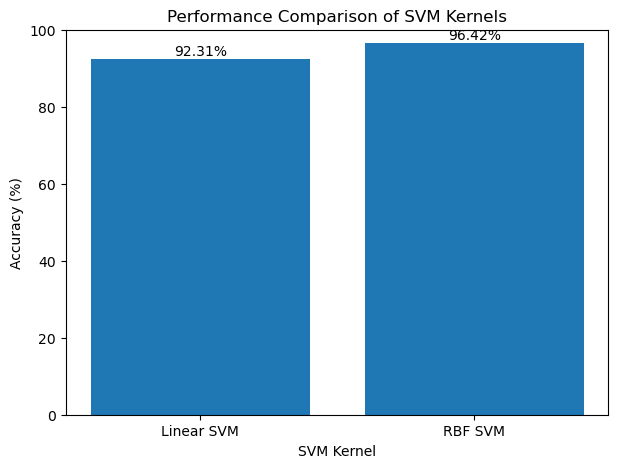

In [18]:
models=['Linear SVM','RBF SVM']
accuracy=[linear_accuracy*100,rbf_accuracy*100]
plt.figure(figsize=(7,5))
bars=plt.bar(models,accuracy)
plt.ylabel("Accuracy (%)")
plt.xlabel("SVM Kernel")
plt.title("Performance Comparison of SVM Kernels")
plt.ylim(0,100)
for bar,value in zip(bars,accuracy):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        value+1,
        f"{value:.2f}%",
        ha='center'
    )
plt.show()